## This is an explainer notebook for the final exam project in the DTU course 02806. 


## 1. Motivation 

### 1.1 What is the dataset

The dataset I have chosen is the New York City "Motor Vehicle Collisions - Crashes" dataset [https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data]. The dataset contain details on crash incidents where each row represents a crash event. The information comes from all police reported motor vehicle collisions in NYC. The police report is required to be filled out for collisions where someone is injured, killed or where there are damages of atleast 1000$.  

### 1.2 Why did I choose this particular dataset

I went with this dataset for two main reasons. Firstly the dataset contain a lot of data (approx 2.25 million rows) and 29 variables that cover everything from geo spatial information to contributing factors, datetimes and detailed information on who got injured/died. This made extensive analysis possible with many different potential angles, which was a very good starting point for the project. Secondly i though that the nature of the dataset was interesting due to the fact that crashes directly affect public health and safety. This makes the dataset interesting since its bot socially relevant, but also well suited for visualization since it can potentially give insight into patterns of when, where and who are affected most by crash harm in New York City. 


### 1.3 What was the goal for the end user experience


The goal was to give the end user a general understanding of the data and the problem of car crashes in NYC. However i also wanted to move the story beyond just a general view of the scale and give a more detailed understanding of when, where and for whom crashes are most harmful. The story is therefore meant to be informative and easy to follow, while also trying to engage the reader to continue to get the full picture of crash harm in NYC.

## 2. Basic stats

### 2.1 Data cleaning and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("MotorVehicleCollisions.csv")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Memory used: ", df.memory_usage(index=True).sum()/10_48_576)

Number of rows: 2253192
Number of columns: 29
Memory used:  498.524356842041


In [5]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

The dataset uses around 500MB of memory and contains over 2 million rows with 29 columns. The columns include temporal information, geospatial coordinates, boroughs, zipcodes, streetlabels, injury/fatality counts, contributing factors and vehicle type codes.

In [6]:
df['COLLISION_ID'].duplicated().sum()

0

Each row represents one crash event. The "COLLISION_ID" is used as an unique incident identifier for the dataset and can be seen to contain no duplicated values. As previously mentioned the crash incidents are police reported data and are only require to be filled out if an injury, fatality or at least a 1000$ worth of damage is present. This means that not all crashes are reported and there might possibly be some bias in the dataset as to what is reported by the police. Therefore the dataset is not a perfect measure of all crash activity in New York City.

In [7]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': df.isna().mean().mul(100).round(2)
}).sort_values('n_missing', ascending=False)

missing.head(20)

,n_missing,pct_missing
VEHICLE TYPE CODE 5,2243302,99.56
CONTRIBUTING FACTOR VEHICLE 5,2242979,99.55
VEHICLE TYPE CODE 4,2217260,98.41
CONTRIBUTING FACTOR VEHICLE 4,2215899,98.34
VEHICLE TYPE CODE 3,2096532,93.05
CONTRIBUTING FACTOR VEHICLE 3,2090099,92.76
OFF STREET NAME,1851532,82.17
CROSS STREET NAME,862706,38.29
ZIP CODE,687745,30.52
BOROUGH,687462,30.51


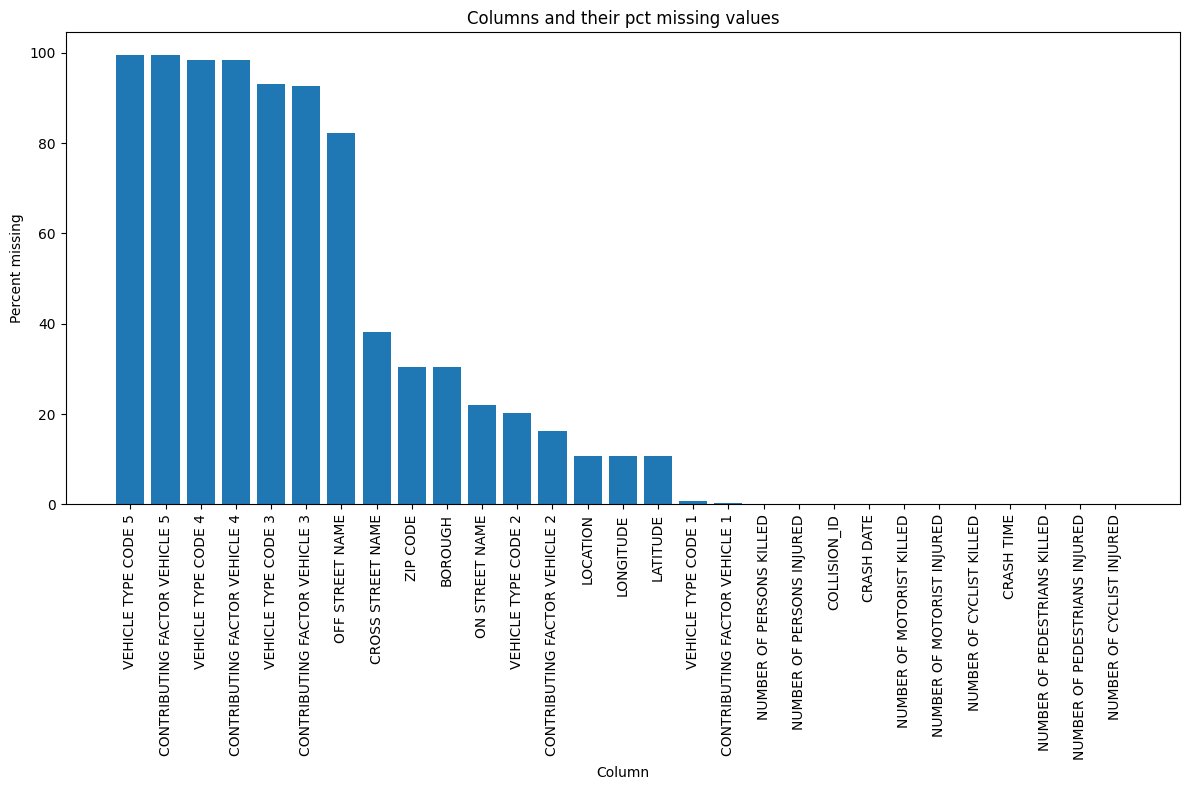

In [8]:
plt.figure(figsize=(12, 8))
plt.bar(missing.index.astype(str), missing["pct_missing"])
plt.xticks(rotation=90)
plt.ylabel("Percent missing")
plt.xlabel("Column")
plt.title("Columns and their pct missing values")
plt.tight_layout()
plt.show()

By inspecting missing values it can be seen from both the table and figure that missingness is highly uneven across variables. Core variables such as "Crash date", "Collision_ID", "Crash time" are complete with most injury/fatality having very few missing values. However several variables from vehicle type code and contributing factor are almost completly missing, which might be due to the fact that there are not many crashes with over three vehicles and contributing factors involved. Street names, borough and zip also has substantial missing values even when the geospatial coordinates are avaliable. Further it can be seen that around 11% of all rows do not contain corrdinates of the incident.   

In [2]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['CRASH DATETIME'] = (
    df['CRASH DATE'].dt.normalize() +
    pd.to_timedelta(df['CRASH TIME'].dt.hour, unit='h') +
    pd.to_timedelta(df['CRASH TIME'].dt.minute, unit='m')
)
print("Date range before cleaning:")
print("Start:", df["CRASH DATETIME"].min())
print("End:", df["CRASH DATETIME"].max())

for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace(['nan', 'None'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

# Drop rows that dont have spatial or temporal information avaliable.
df_clean =df.dropna(subset=['LATITUDE', 'LONGITUDE','CRASH DATETIME','NUMBER OF PERSONS KILLED','NUMBER OF PERSONS INJURED']).copy()
df_clean.head()
df_clean = df_clean.drop(columns=['CRASH DATE', 'CRASH TIME','LOCATION','VEHICLE TYPE CODE 5','CONTRIBUTING FACTOR VEHICLE 5',
                 'VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 3','CONTRIBUTING FACTOR VEHICLE 4','CONTRIBUTING FACTOR VEHICLE 3',
                 "OFF STREET NAME"])

df_clean = df_clean[~df_clean["CRASH DATETIME"].dt.year.isin([2012, 2026])].copy()
print("Date range after cleaning:")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Date range before cleaning:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00
Date range after cleaning:
Start: 2013-01-01 00:01:00
End: 2025-12-31 23:58:00


The crash date and crash time varaibles are merged to a combined "Crash datetime" variable. For further analysis all rows with missing geospatial coordinates and number of person/injury are removed since these are important variables that are central in my analysis. Also variables that are not gonna be used in the analysis or variables that contain extreme number of missing values are removed. Also since the dataset contain incomplete data for years 2012 and 2026 they are removed such that the data starts in 2013 and ends in 2025. 

In [3]:
import geopandas as gpd
from shapely.geometry import Point
df_boro = df_clean.copy()

df_boro["BOROUGH"] = (
    df_boro["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)
gdf_crashes = gpd.GeoDataFrame(
    df_boro,
    geometry=gpd.points_from_xy(df_boro["LONGITUDE"], df_boro["LATITUDE"]),
    crs="EPSG:4326"
)

borough_geojson_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boro_gdf = gpd.read_file(borough_geojson_url)
boro_gdf_match = boro_gdf.copy()

if boro_gdf_match.crs is None:
    boro_gdf_match = boro_gdf_match.set_crs("EPSG:4326")
elif boro_gdf_match.crs != gdf_crashes.crs:
    boro_gdf_match = boro_gdf_match.to_crs(gdf_crashes.crs)

possible_boro_cols = ["boroname"]
boro_name_col = next((c for c in possible_boro_cols if c in boro_gdf_match.columns), None)

if boro_name_col is None:
    raise ValueError("Could not find borough name column in boro_gdf")

boro_lookup = boro_gdf_match[[boro_name_col, "geometry"]].copy()

gdf_joined = gpd.sjoin(
    gdf_crashes,
    boro_lookup,
    how="left",
    predicate="within"
)

needs_fill = gdf_joined["BOROUGH"].str.lower().isin(["unspecified","nan"])

gdf_joined.loc[needs_fill, "BOROUGH"] = gdf_joined.loc[needs_fill, boro_name_col].str.upper()

gdf_joined["BOROUGH"] = gdf_joined["BOROUGH"].fillna("Unspecified")

df_clean_filled = df_clean.copy()
df_clean_filled["BOROUGH"] = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)

df_clean_filled.loc[gdf_joined.index, "BOROUGH"] = gdf_joined["BOROUGH"]

before_unspecified = (
    df_clean["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", ""])
).sum()

after_unspecified = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", ""])
).sum()

print(f"Unspecified boroughs before fill: {before_unspecified}")
print(f"Unspecified boroughs after fill:  {after_unspecified}")

Unspecified boroughs before fill: 472110
Unspecified boroughs after fill:  9896


Many rows with missing the borough label while having valid geospatial coordinates. To improve on the borough level analysis, I spatially joined crash coordinates to New York City borough polygons and used these to fill in as many borough labels as possible. As seen we went from having 472.110 missing borough values to 9896, meaning that most boroughs were able to be filled in. The rest of the boroughs that could not be filled in are removed from the data:

In [6]:
df_clean = df_clean_filled.copy()
df_clean = df_clean[
    ~df_clean["BOROUGH"].isin(["Unspecified"])
].copy()
df_clean["BOROUGH"].unique()

array(['BROOKLYN', 'BRONX', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'],
      dtype=object)

After removing the approximately 10.000 rows that could not be filled with boroughs, the only boroughs that are left in the dataset are now the five correct NYC boroughs. 

In [8]:
is_kill_bal = df["NUMBER OF PERSONS KILLED"] == df["NUMBER OF MOTORIST KILLED"] + df["NUMBER OF CYCLIST KILLED"] + df["NUMBER OF PEDESTRIANS KILLED"]
print(len(is_kill_bal[is_kill_bal==False]))
is_inj_bal = df["NUMBER OF PERSONS INJURED"] == df["NUMBER OF MOTORIST INJURED"] + df["NUMBER OF CYCLIST INJURED"] + df["NUMBER OF PEDESTRIANS INJURED"]
print(len(is_inj_bal[is_inj_bal==False]))

113
10640


One thing that i could not find an exact definition on in the raw dataset was whether the number of person injured/killed represented the sum of the three subcategories. By checking this it can be seen that for most rows it do indeed match, however there are some inconsistensies still. These inconsistensies might be caused by passenger differences or possbly recording mistakes. Since the mismatches were limited, I decided to treat number of persons injured/killed as the total sum of the subcategories hence i removed all the rows that had these mismatches to ensure consistency. 

In [9]:
df_clean = df_clean.copy()
df_clean = df_clean[
    ~(
        (df_clean["NUMBER OF PERSONS INJURED"] != (
            df_clean["NUMBER OF PEDESTRIANS INJURED"]
            + df_clean["NUMBER OF CYCLIST INJURED"]
            + df_clean["NUMBER OF MOTORIST INJURED"]
        ))
        |
        (df_clean["NUMBER OF PERSONS KILLED"] != (
            df_clean["NUMBER OF PEDESTRIANS KILLED"]
            + df_clean["NUMBER OF CYCLIST KILLED"]
            + df_clean["NUMBER OF MOTORIST KILLED"]
        ))
    )
].copy()

In [13]:
print(df_clean.shape)
print(df.shape[0]-df_clean.shape[0])

(1887039, 20)
366153


After data-preprocessing there are a little under 1.9 million incidents left and 20 variables. This means that 366153 incidents were removed, most of which due to not having geospatial information avaliable. Further 9 variables were removed since they either had too many missing values or were not useful for the analysis. 

### 2.2 Write a section that discuss the dataset stats and that contain key plots from the exploratory data analysis

## 3. Data analysis

* Describe your data analysis and explain what i have learned about the dataset
* If relevant, talk about my machine learning <- not relevant in this case i guess.

## 4. Genre

* Tools i used from each of the three categories of visual narrative and why?
* Tools i used from each of the three categories of visual structure and why?
* Segal and Heer paper


## 5. Visualizations

* Explain the visualizations i have chosen
* Why are they right for telling this story?

* Q: Should i have the visualizations inside the notebook here?

## 6. Discussion

* What went well?
* What is still missing? What would be improved?, Why?

## 7. Contributions

* This entire project is made by Magnus Elfenbein s214710